In [1]:
import sklearn
import xgboost as xgb
import numpy as np
from xgboost import plot_tree
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import pickle
with open("Dictionaries/origin_rate_dict.pkl", "rb") as f:
    origin_rate_dict = pickle.load(f)
    
with open("Dictionaries/destination_rate_dict.pkl", "rb") as f:
    destination_rate_dict = pickle.load(f)

with open("Dictionaries/vendors_dict.pkl", "rb") as f:
    vendors_dict = pickle.load(f)
    
with open("Dictionaries/unique_vendors.pkl", "rb") as f:
    unique_vendors = pickle.load(f)

with open("Dictionaries/origin_rate_dict.pkl", "rb") as f:
    origin_rate_dict = pickle.load(f)

with open("Dictionaries/journey_mileage_dict.pkl", "rb") as f:
    journey_mileage_dict = pickle.load(f)

with open("Dictionaries/journey_duration_dict.pkl", "rb") as f:
    journey_duration_dict = pickle.load(f)

In [3]:
def peak_pred(first_departure_minute):
    peak_bool = (first_departure_minute >= 7*60) & (first_departure_minute < 9*60) | (first_departure_minute >= 21*60) & (first_departure_minute < 23*60)
    return peak_bool

def pred_AB(route_string, week_day, search_horizon_hours, first_departure_minute):
    duration = journey_duration_dict[route_string]
    mileage = journey_mileage_dict[route_string]
    vendor = vendors_dict[route_string]
    #origin_congest = origin_rate_dict[route_string]
    #destination_congest = destination_rate_dict[route_string]
    num_stops = route_string.split(',').__len__()
    speed = mileage / duration
    peak_bool = peak_pred(first_departure_minute)
    num_vendors = 1
    num_pipes = 0
    uv_d = {uv:0 for uv in unique_vendors}
    for v in vendor:
        uv_d[v] = 1
    route_dict = {
        'journey_duration': duration, 
        'journey_mileage': mileage, 
        'num_intermediate_points': num_stops, 
        'speed': speed, 
        'peak_hour': peak_bool, 
        'num_vendors': num_vendors, 
        'vendor': vendor, 
        'num_pipes': num_pipes,
        'weekday': week_day,
        'search_horizon_hours': search_horizon_hours,
        "departure_minute": first_departure_minute,
        #'origin_congest': origin_congest,
        #'destination_congest': destination_congest,
    }
    route_dict.update(uv_d)
    return route_dict

In [4]:
# Load and xgboost model from file

loaded_model = xgb.Booster()
loaded_model.load_model('xgb_model.ubj')

In [6]:
inter = ['KGX', 'PBO', 'NNG', 'DON', 'YRK', 'NTR', 'DAR', 'DHM', 'NCL', 'EDB']

all_posible_routes = []
for i in range(len(inter)):
    for j in range(i+1, len(inter)):
        all_posible_routes.append(",".join(inter[i:j+1]))
all_posible_routes

['KGX,PBO',
 'KGX,PBO,NNG',
 'KGX,PBO,NNG,DON',
 'KGX,PBO,NNG,DON,YRK',
 'KGX,PBO,NNG,DON,YRK,NTR',
 'KGX,PBO,NNG,DON,YRK,NTR,DAR',
 'KGX,PBO,NNG,DON,YRK,NTR,DAR,DHM',
 'KGX,PBO,NNG,DON,YRK,NTR,DAR,DHM,NCL',
 'KGX,PBO,NNG,DON,YRK,NTR,DAR,DHM,NCL,EDB',
 'PBO,NNG',
 'PBO,NNG,DON',
 'PBO,NNG,DON,YRK',
 'PBO,NNG,DON,YRK,NTR',
 'PBO,NNG,DON,YRK,NTR,DAR',
 'PBO,NNG,DON,YRK,NTR,DAR,DHM',
 'PBO,NNG,DON,YRK,NTR,DAR,DHM,NCL',
 'PBO,NNG,DON,YRK,NTR,DAR,DHM,NCL,EDB',
 'NNG,DON',
 'NNG,DON,YRK',
 'NNG,DON,YRK,NTR',
 'NNG,DON,YRK,NTR,DAR',
 'NNG,DON,YRK,NTR,DAR,DHM',
 'NNG,DON,YRK,NTR,DAR,DHM,NCL',
 'NNG,DON,YRK,NTR,DAR,DHM,NCL,EDB',
 'DON,YRK',
 'DON,YRK,NTR',
 'DON,YRK,NTR,DAR',
 'DON,YRK,NTR,DAR,DHM',
 'DON,YRK,NTR,DAR,DHM,NCL',
 'DON,YRK,NTR,DAR,DHM,NCL,EDB',
 'YRK,NTR',
 'YRK,NTR,DAR',
 'YRK,NTR,DAR,DHM',
 'YRK,NTR,DAR,DHM,NCL',
 'YRK,NTR,DAR,DHM,NCL,EDB',
 'NTR,DAR',
 'NTR,DAR,DHM',
 'NTR,DAR,DHM,NCL',
 'NTR,DAR,DHM,NCL,EDB',
 'DAR,DHM',
 'DAR,DHM,NCL',
 'DAR,DHM,NCL,EDB',
 'DHM,NCL',
 'DHM,NC

In [7]:
weekday = 1
search_horizon_hours = 31 * 24

In [8]:
test = pd.DataFrame.from_dict(pred_AB(all_posible_routes[0], weekday, search_horizon_hours, 12*60))

In [9]:
features = [
    'weekday', 
    'departure_minute', 
    'search_horizon_hours', 
    'journey_mileage', 
    'journey_duration', 
    'speed', 
    'peak_hour',
    'num_intermediate_points',
    'num_vendors',
    'num_pipes' # Prob remove
]
features.extend(unique_vendors)
target = 'cheapest_standard_class'

In [10]:
loaded_model.predict(xgb.DMatrix(data=test[features], enable_categorical=True))

array([23.818686], dtype=float32)

In [11]:
import networkx as nx
from tqdm import tqdm

graph = nx.DiGraph()

weekday = 1
search_horizon_hours = 31 * 24

for route in tqdm(all_posible_routes):
    tmp = route.split(",")
    start = inter.index(tmp[0])
    end = inter.index(tmp[-1])
    
    inputs = pd.DataFrame.from_dict(pred_AB(route, weekday, search_horizon_hours, 12*60))
    cost = loaded_model.predict(xgb.DMatrix(data=inputs[features], enable_categorical=True)).tolist()
    
    graph.add_edge(start, end, weight=round(cost[0], 2))

100%|██████████| 45/45 [00:00<00:00, 110.69it/s]


{(0, 1): Text(0.5000002477318048, 0.0, "{'weight': 23.82}"),
 (0, 2): Text(0.9999732701107855, 0.0, "{'weight': 31.32}"),
 (0, 3): Text(1.5000097987940535, 0.0, "{'weight': 34.74}"),
 (0, 4): Text(1.9999559004791072, 0.0, "{'weight': 30.71}"),
 (0, 5): Text(2.500030233495637, 0.0, "{'weight': 52.34}"),
 (0, 6): Text(3.00002374505857, 0.0, "{'weight': 77.34}"),
 (0, 7): Text(3.5000085811770987, 0.0, "{'weight': 77.15}"),
 (0, 8): Text(3.9999631012324235, 0.0, "{'weight': 100.06}"),
 (0, 9): Text(4.500010569841832, 0.0, "{'weight': 95.72}"),
 (1, 2): Text(1.500000247731804, 0.0, "{'weight': 17.26}"),
 (1, 3): Text(1.999973270110786, 0.0, "{'weight': 21.35}"),
 (1, 4): Text(2.5000097987940535, 0.0, "{'weight': 32.5}"),
 (1, 5): Text(2.999955900479107, 0.0, "{'weight': 27.58}"),
 (1, 6): Text(3.500030233495636, 0.0, "{'weight': 31.17}"),
 (1, 7): Text(4.00002374505857, 0.0, "{'weight': 37.87}"),
 (1, 8): Text(4.500008581177097, 0.0, "{'weight': 43.82}"),
 (1, 9): Text(4.999963101232423, 0.

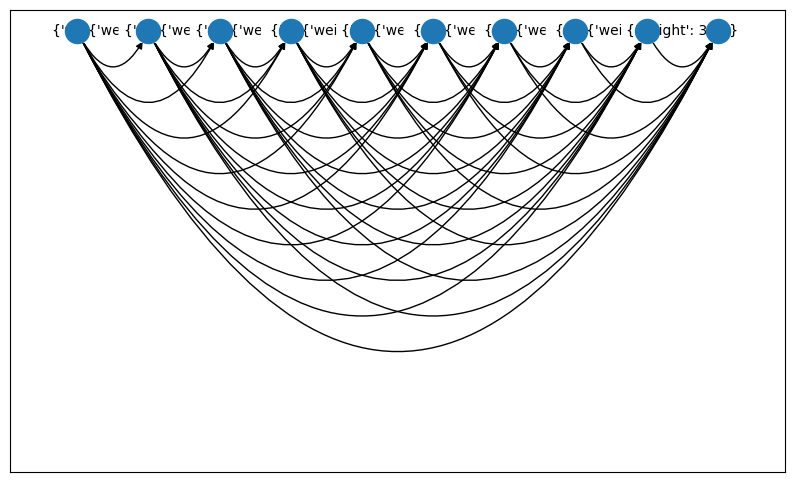

In [12]:
pos = {u: (u, 0) for u in graph.nodes()}

fig, ax = plt.subplots(figsize=(10, 6))
nx.draw_networkx_nodes(graph, pos, ax=ax)
nx.draw_networkx_edges(
    graph, pos,
    connectionstyle="arc3,rad=1",
    arrows=True,
    ax=ax
)
edge_labels = nx.get_edge_attributes(graph, 'weight')

# Draw edge labels
nx.draw_networkx_edge_labels(graph, pos)

In [17]:
aug_graph = nx.DiGraph()

k = 1
N = len(inter)

for u, v in graph.edges():
    for i in range(k):
        if (i == 0 and u !=0) or (i == k-1 and v != N-1) or (i > u):
            continue
        aug_graph.add_edge((i, u), (i + 1, v), w=graph[u][v]['weight'])

for i in range(1, k):
    aug_graph.add_edge((i, N-1), (i+1, N-1), w=0)

{((0, 0), (1, 9)): Text(0.5000010440562621, 5.499990603493643, "{'w': 95.72}")}

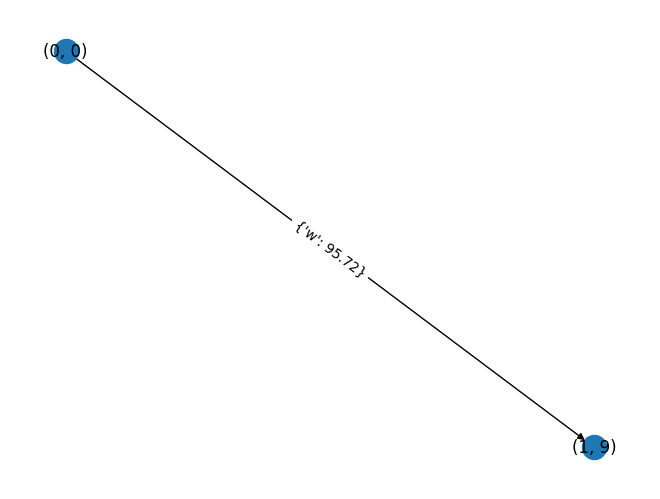

In [18]:
positions = {node: (node[0], N - node[1]) for node in aug_graph.nodes()}

nx.draw(aug_graph, pos=positions, with_labels=True)
nx.draw_networkx_edge_labels(aug_graph, positions)

In [19]:
path = nx.shortest_path(aug_graph, (0, 0), (k, N-1), weight='w')

for _, station in path:
    print(inter[station])

KGX
EDB


In [20]:
print(nx.shortest_path_length(aug_graph, (0, 0), (k, N-1), weight='w'))

95.72
